<a href="https://colab.research.google.com/github/HimanshuSingh0912/MedicalCostPrediction/blob/main/MedicalCostPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Medical Cost Prediction - Linear Regression Model


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# **1. Load Dataset**

---



In [15]:

insurance_df = pd.read_csv('/content/insurance (1).csv')
insurance_df = pd.get_dummies(insurance_df, drop_first=True)
print('Shape:', insurance_df.shape)
insurance_df.head()

Shape: (1338, 9)


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [9]:

insurance_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   bmi               1338 non-null   float64
 2   children          1338 non-null   int64  
 3   charges           1338 non-null   float64
 4   sex_male          1338 non-null   bool   
 5   smoker_yes        1338 non-null   bool   
 6   region_northwest  1338 non-null   bool   
 7   region_southeast  1338 non-null   bool   
 8   region_southwest  1338 non-null   bool   
dtypes: bool(5), float64(2), int64(2)
memory usage: 48.5 KB


In [16]:

insurance_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [48]:
insurance_df['charges'] = np.log(insurance_df['charges'])
insurance_df['bmi_smoker'] = insurance_df['bmi'] * insurance_df['smoker_yes']

# **2. Data Cleaning and Preprocessing**

In [49]:

print('Null values before treatment:')
print(insurance_df.isnull().sum())

Null values before treatment:
age                 0
bmi                 0
children            0
charges             0
sex_male            0
smoker_yes          0
region_northwest    0
region_southeast    0
region_southwest    0
bmi_smoker          0
dtype: int64


# **Label Encoding (Categorical → Numeric)**

In [50]:
le = LabelEncoder()
cat_cols_insurance = insurance_df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols_insurance)

for col in cat_cols_insurance:
    insurance_df[col] = le.fit_transform(insurance_df[col].astype(str))

insurance_df.head()

Categorical columns: []


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_smoker
0,19,27.900,0,0.822263,False,True,False,False,True,27.9
1,18,33.770,1,0.697466,True,False,False,True,False,0.0
2,28,33.000,3,0.755322,True,False,False,True,False,0.0
3,33,22.705,0,0.833950,True,False,True,False,False,0.0
4,32,28.880,0,0.747374,True,False,True,False,False,0.0


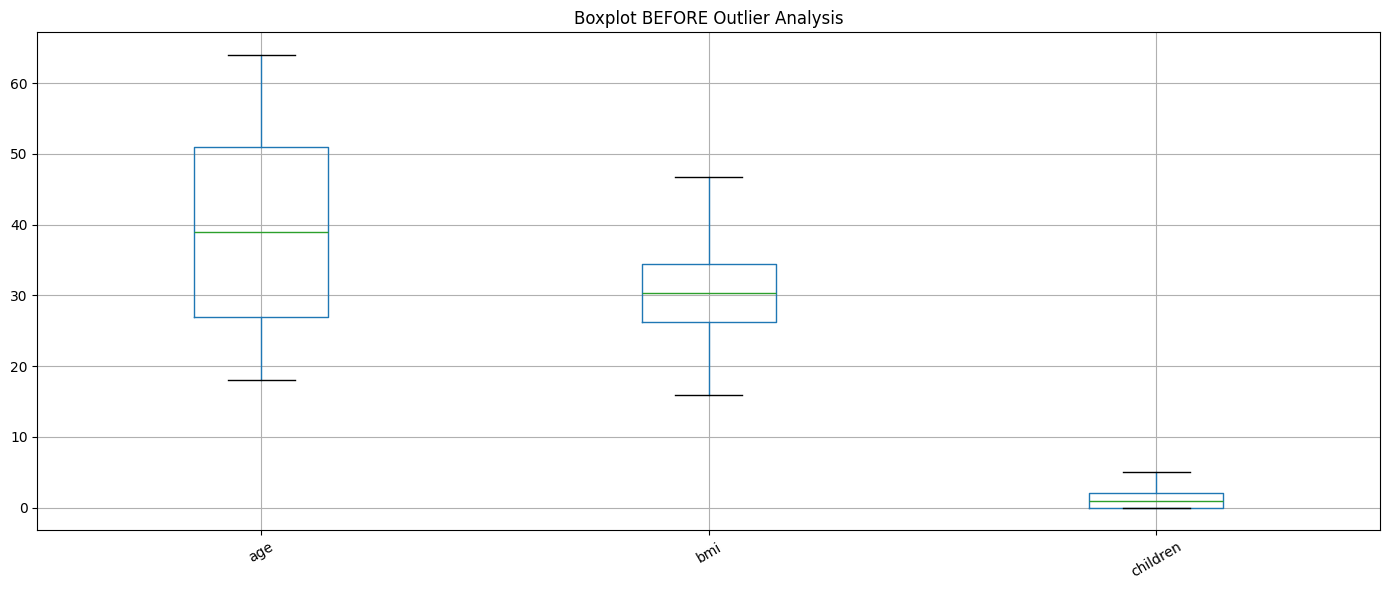

In [51]:
num_cols_insurance = insurance_df.select_dtypes(include=np.number).columns.tolist()
num_cols_insurance = [c for c in num_cols_insurance if c != 'charges']


num_cols_insurance = ['age', 'bmi', 'children']

plt.figure(figsize=(14, 6))
insurance_df[num_cols_insurance].boxplot(rot=30)
plt.title('Boxplot BEFORE Outlier Analysis')
plt.tight_layout()
plt.show()

In [52]:
num_cols_insurance = ['age', 'bmi', 'children']  # ONLY continuous variables

df = insurance_df.copy()

print('Rows before outlier removal:', len(df))

for col in num_cols_insurance:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print('Rows after outlier removal:', len(df))

insurance_df = df

Rows before outlier removal: 1329
Rows after outlier removal: 1329


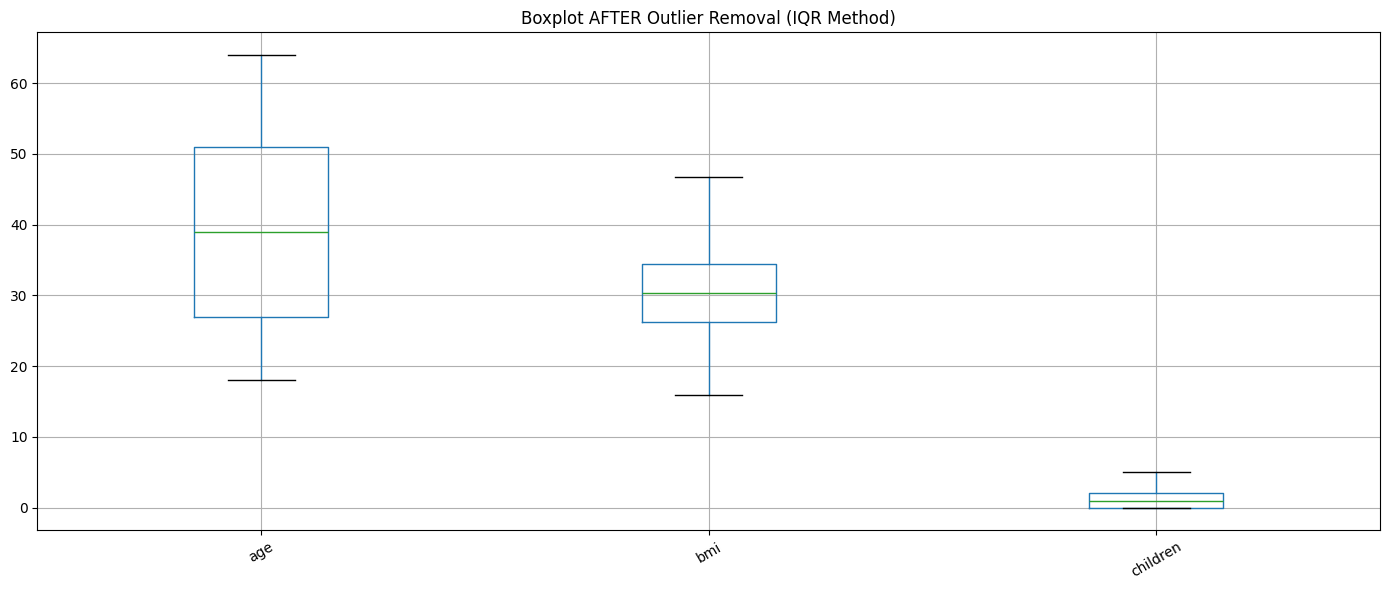

In [53]:

plt.figure(figsize=(14, 6))
insurance_df[num_cols_insurance].boxplot(rot=30)
plt.title('Boxplot AFTER Outlier Removal (IQR Method)')
plt.tight_layout()
plt.show()

# **3. Visualizations**

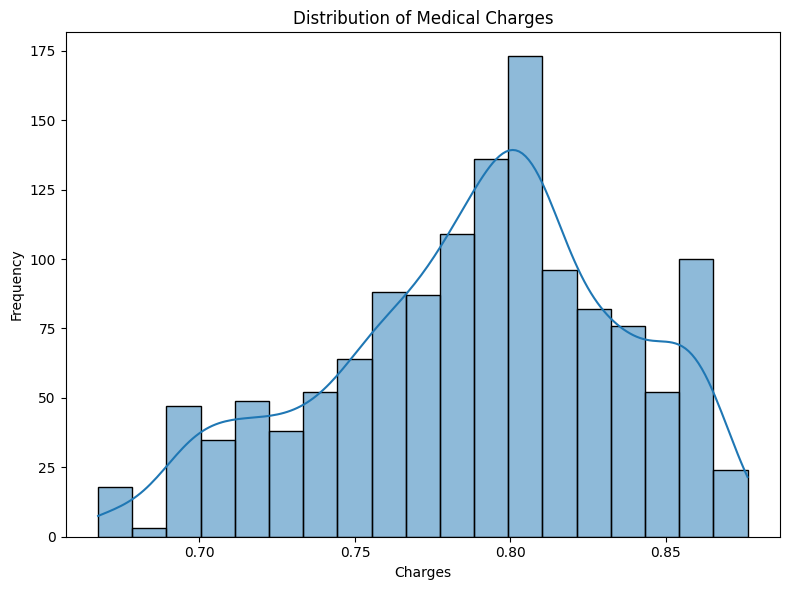

In [54]:
plt.figure(figsize=(8, 6))
sns.histplot(insurance_df['charges'], kde=True)
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

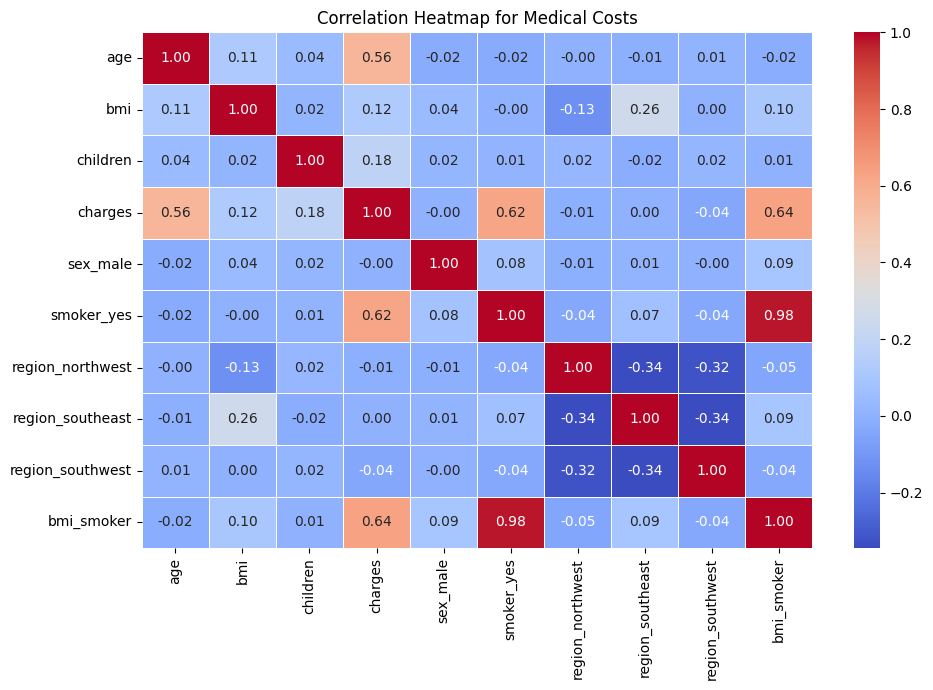

In [55]:
plt.figure(figsize=(10, 7))
corr_insurance = insurance_df.corr()
sns.heatmap(corr_insurance, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap for Medical Costs')
plt.tight_layout()
plt.show()

# **4. Model Training - Linear Regression**

In [56]:
# Define features
X_insurance = insurance_df.drop(columns=['charges'])
y_insurance = insurance_df['charges']


X_train_insurance, X_test_insurance, y_train_insurance, y_test_insurance = train_test_split(
    X_insurance, y_insurance, test_size=0.2, random_state=42
)

print('Insurance Train size:', X_train_insurance.shape)
print('Insurance Test size :', X_test_insurance.shape)

# Train Linear Regression model
insurance_model = LinearRegression()
insurance_model.fit(X_train_insurance, y_train_insurance)

Insurance Train size: (1063, 9)
Insurance Test size : (266, 9)


LinearRegression()

Mean Absolute Error (MAE): 0.01
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.02
R-squared (R2): 0.7438


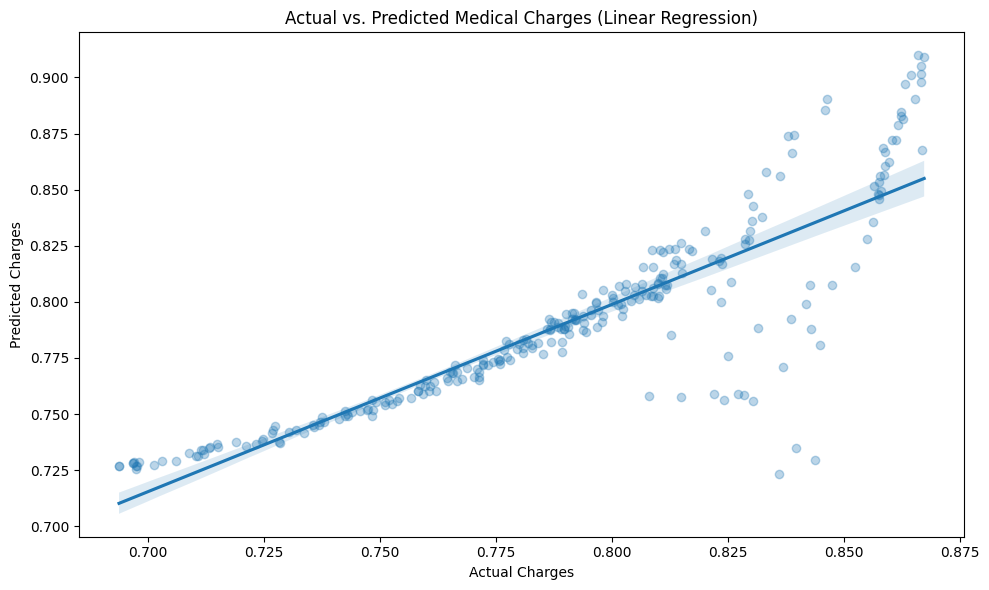

In [57]:
y_pred_insurance = insurance_model.predict(X_test_insurance)

# Evaluate Regression Model
mae = mean_absolute_error(y_test_insurance, y_pred_insurance)
mse = mean_squared_error(y_test_insurance, y_pred_insurance)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_insurance, y_pred_insurance)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R2): {r2:.4f}')

# Visualize Predictions vs Actual
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test_insurance, y=y_pred_insurance, scatter_kws={'alpha':0.3})
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs. Predicted Medical Charges (Linear Regression)')
plt.tight_layout()
plt.show()